# 10. Twitter vs Assemblée nationale — Comparaison formalisée

Ce notebook formalise la comparaison entre les deux arènes (Twitter et interventions à l'Assemblée nationale) pour les députés actifs sur les deux. On calcule l'écart de stance (Δ = stance_Twitter − stance_AN), on le modélise par régression, et on trace son évolution temporelle par bloc. Méthode inspirée de Çetinkaya et al. (2025, AAAI).

## Setup

In [1]:
import sys
from pathlib import Path
import re
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import CORPUS_V3, BLOC_ORDER, BLOC_COLORS, EVENTS, BATCHES, add_events, format_dates

FIG_DIR = Path("../figures")
RES_DIR = Path("../data/results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight'})

def save(name):
    plt.savefig(FIG_DIR / f"{name}.png")
    plt.show()

## Chargement et normalisation des auteurs

Les interventions AN utilisent le préfixe « M. » ou « Mme » ; on normalise pour matcher les députés actifs sur les deux arènes.

In [2]:
df = pd.read_parquet(CORPUS_V3)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)
df['author_norm'] = df['author'].str.replace(r'^(M\.?|Mme)\s+', '', regex=True).str.strip()
df = df[df['bloc'].isin(BLOC_ORDER)]

tw_authors = set(df[df['arena'] == 'Twitter']['author_norm'].unique())
an_authors = set(df[df['arena'] == 'AN']['author_norm'].unique())
both_authors = tw_authors & an_authors
print(f"Députés actifs sur Twitter et AN : {len(both_authors)}")

Députés actifs sur Twitter et AN : 127


## Stance par député-mois et Delta

In [3]:
df_both = df[df['author_norm'].isin(both_authors)].copy()
stance_tw = df_both[df_both['arena'] == 'Twitter'].groupby(['author_norm', 'month', 'bloc']).agg(
    stance_tw=('stance_v3', 'mean'),
    n_tweets=('stance_v3', 'count'),
    engagement_mean=('engagement', 'mean')
).reset_index()
stance_an = df_both[df_both['arena'] == 'AN'].groupby(['author_norm', 'month', 'bloc']).agg(
    stance_an=('stance_v3', 'mean'),
    n_an=('stance_v3', 'count')
).reset_index()

merged = stance_tw.merge(
    stance_an,
    on=['author_norm', 'month', 'bloc'],
    how='inner'
)
merged['delta'] = merged['stance_tw'] - merged['stance_an']
merged['month_ts'] = pd.to_datetime(merged['month'] + '-01')
merged.to_csv(RES_DIR / 'stance_twitter_vs_an_by_deputy.csv', index=False)
print(f"Observations député-mois (les deux arènes) : {len(merged)}")

Observations député-mois (les deux arènes) : 231


## Régression Delta ~ bloc + n_tweets + engagement + month

In [4]:
import statsmodels.formula.api as smf

def month_to_batch(m):
    d = pd.Timestamp(m + '-15')
    for name, r in BATCHES.items():
        if pd.Timestamp(r['start']) <= d <= pd.Timestamp(r['end']): return name
    return 'OTHER'
merged['batch'] = merged['month'].apply(month_to_batch)
merged_clean = merged.dropna(subset=['delta', 'n_tweets', 'engagement_mean'])
if len(merged_clean) >= 20:
    model = smf.ols('delta ~ C(bloc) + n_tweets + engagement_mean + C(batch)', data=merged_clean).fit()
    reg_summary = pd.DataFrame({
        'param': model.params.index,
        'coef': model.params.values,
        'pvalue': model.pvalues.values
    })
    reg_summary.to_csv(RES_DIR / 'regression_delta_stance.csv', index=False)
    print(model.summary().tables[1])

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.0317      0.268      0.118      0.906      -0.496       0.560
C(bloc)[T.Droite]             -0.1516      0.234     -0.649      0.517      -0.612       0.309
C(bloc)[T.Gauche moderee]     -0.4191      0.277     -1.512      0.132      -0.966       0.127
C(bloc)[T.Gauche radicale]     0.5036      0.196      2.573      0.011       0.118       0.889
C(batch)[T.CHOC]               0.1196      0.268      0.446      0.656      -0.409       0.648
C(batch)[T.NEW_OFFENSIVE]     -0.0456      0.253     -0.181      0.857      -0.543       0.452
C(batch)[T.OTHER]             -0.3208      0.690     -0.465      0.643      -1.681       1.040
C(batch)[T.POST_CIJ]          -0.0966      0.314     -0.307      0.759      -0.716       0.523
C(batch)[T.POST_SINWAR]       -0.1685      0.407  

## Fig 64 : Distribution Delta par bloc (violin)

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_14924\381424258.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_plot, x='bloc', y='delta', order=order,


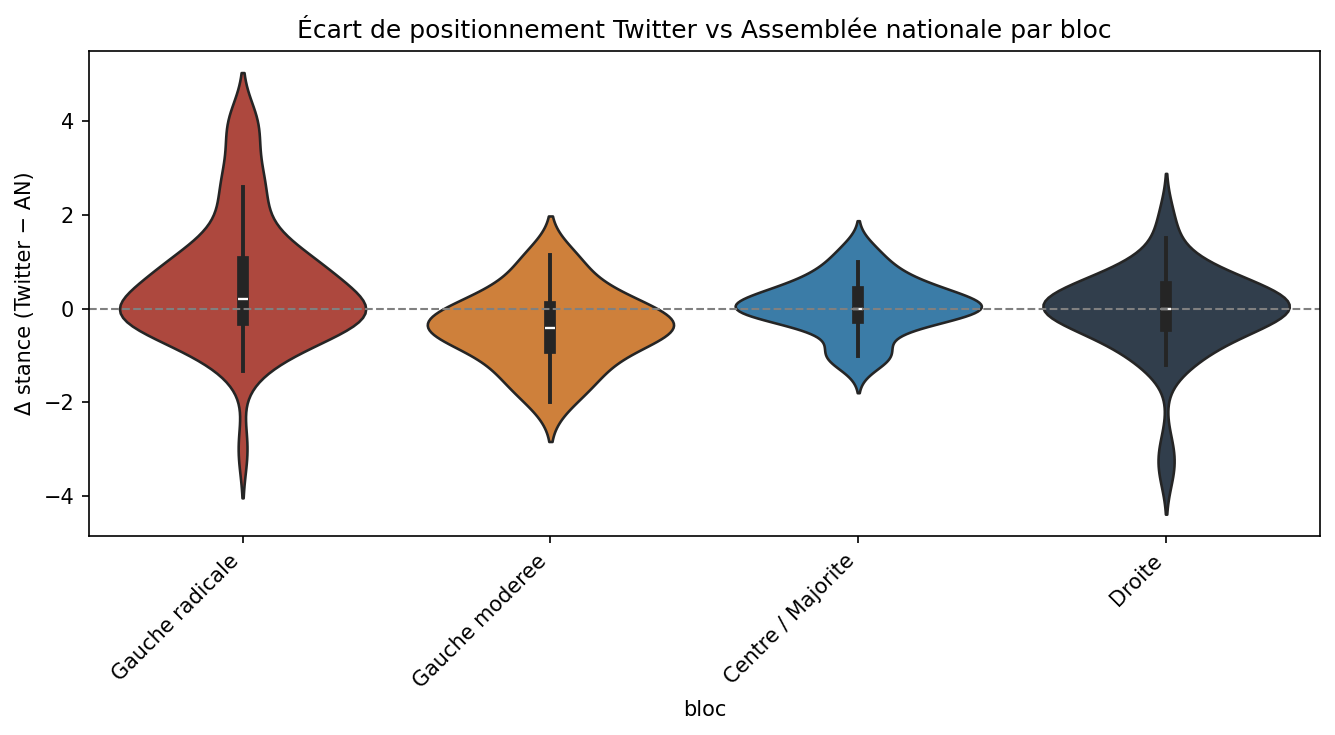

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
order = [b for b in BLOC_ORDER if b in merged['bloc'].values]
data_plot = merged[merged['bloc'].isin(order)].copy()
data_plot['bloc'] = pd.Categorical(data_plot['bloc'], categories=order)
sns.violinplot(data=data_plot, x='bloc', y='delta', order=order,
               palette=[BLOC_COLORS.get(b, '#888') for b in order])
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_ylabel('Δ stance (Twitter − AN)')
ax.set_title('Écart de positionnement Twitter vs Assemblée nationale par bloc')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save('fig64_delta_stance_by_bloc')

## Fig 65 : Delta temporel par bloc

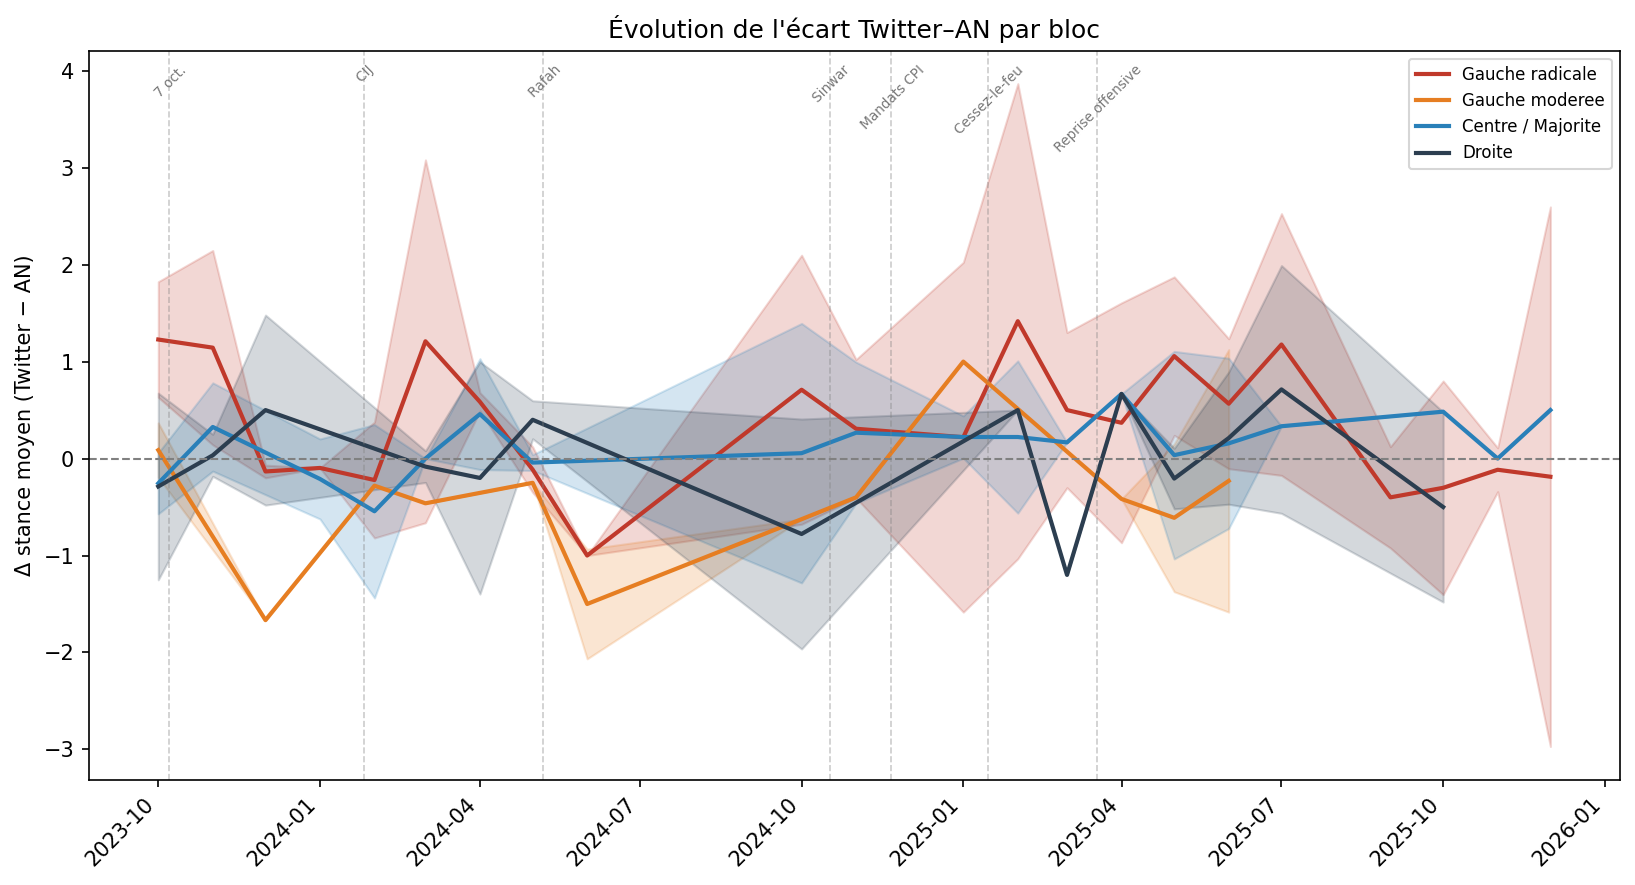

In [6]:
delta_agg = merged.groupby(['month', 'bloc']).agg(delta_mean=('delta', 'mean'), delta_se=('delta', 'sem'), n=('delta', 'count')).reset_index()
delta_agg['month_ts'] = pd.to_datetime(delta_agg['month'] + '-01')

fig, ax = plt.subplots(figsize=(11, 6))
for bloc in BLOC_ORDER:
    sub = delta_agg[delta_agg['bloc'] == bloc]
    if len(sub) > 0:
        se = sub['delta_se'].fillna(0)
        ax.plot(sub['month_ts'], sub['delta_mean'], label=bloc, color=BLOC_COLORS.get(bloc, '#888'), lw=2)
        ax.fill_between(sub['month_ts'], sub['delta_mean'] - 1.96*se, sub['delta_mean'] + 1.96*se, alpha=0.2, color=BLOC_COLORS.get(bloc, '#888'))
ax.axhline(0, color='gray', ls='--', lw=1)
add_events(ax)
ax.set_ylabel('Δ stance moyen (Twitter − AN)')
ax.set_title('Évolution de l\'écart Twitter–AN par bloc')
ax.legend(loc='upper right', fontsize=8)
format_dates(ax)
plt.tight_layout()
save('fig65_delta_stance_temporal')